<a href="https://colab.research.google.com/github/Ed559/enconto-site/blob/main/quantai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  OTIMIZADOR DE CARTEIRA — PROTÓTIPO v1
  Tickers    : ['PETR4.SA', 'WEGE3.SA', 'ITUB4.SA', 'VALE3.SA', 'RENT3.SA']
  Benchmark  : ^BVSP
  CDI anual  : 10.65%
  Período    : 5y
  Pesos      : [0%, 40%]  |  Long only
  Rebalanc.  : Anual

📥 Baixando dados: ['PETR4.SA', 'WEGE3.SA', 'ITUB4.SA', 'VALE3.SA', 'RENT3.SA'] + benchmark ^BVSP...
✅ 1246 dias úteis (2021-06-22 → 2026-06-19)

📐 Calculando métricas individuais...
⚙️  Otimizando carteira (Markowitz)...
🎲 Simulando 5000 portfólios (Monte Carlo)...

  CARTEIRA ÓTIMA (Máx Sharpe)
  Retorno Anual      :    26.30%
  Volatilidade       :    20.06%
  Sharpe             :    0.780
  Sortino            :    1.144
  Beta               :    0.912
  Retorno CAPM       :     7.48%
  Alfa de Jensen     :    18.82%
  MDD                :   -24.93%
  CVaR 5%  (diário)  :    -2.80%
  Tracking Error     :    12.07%
  Information Ratio  :    1.362
  Rolling Sharpe (med):   0.895
  Calmar             :    1.055

  CARTEIRA MÍNIMA VARIÂNCIA
  Retorno An

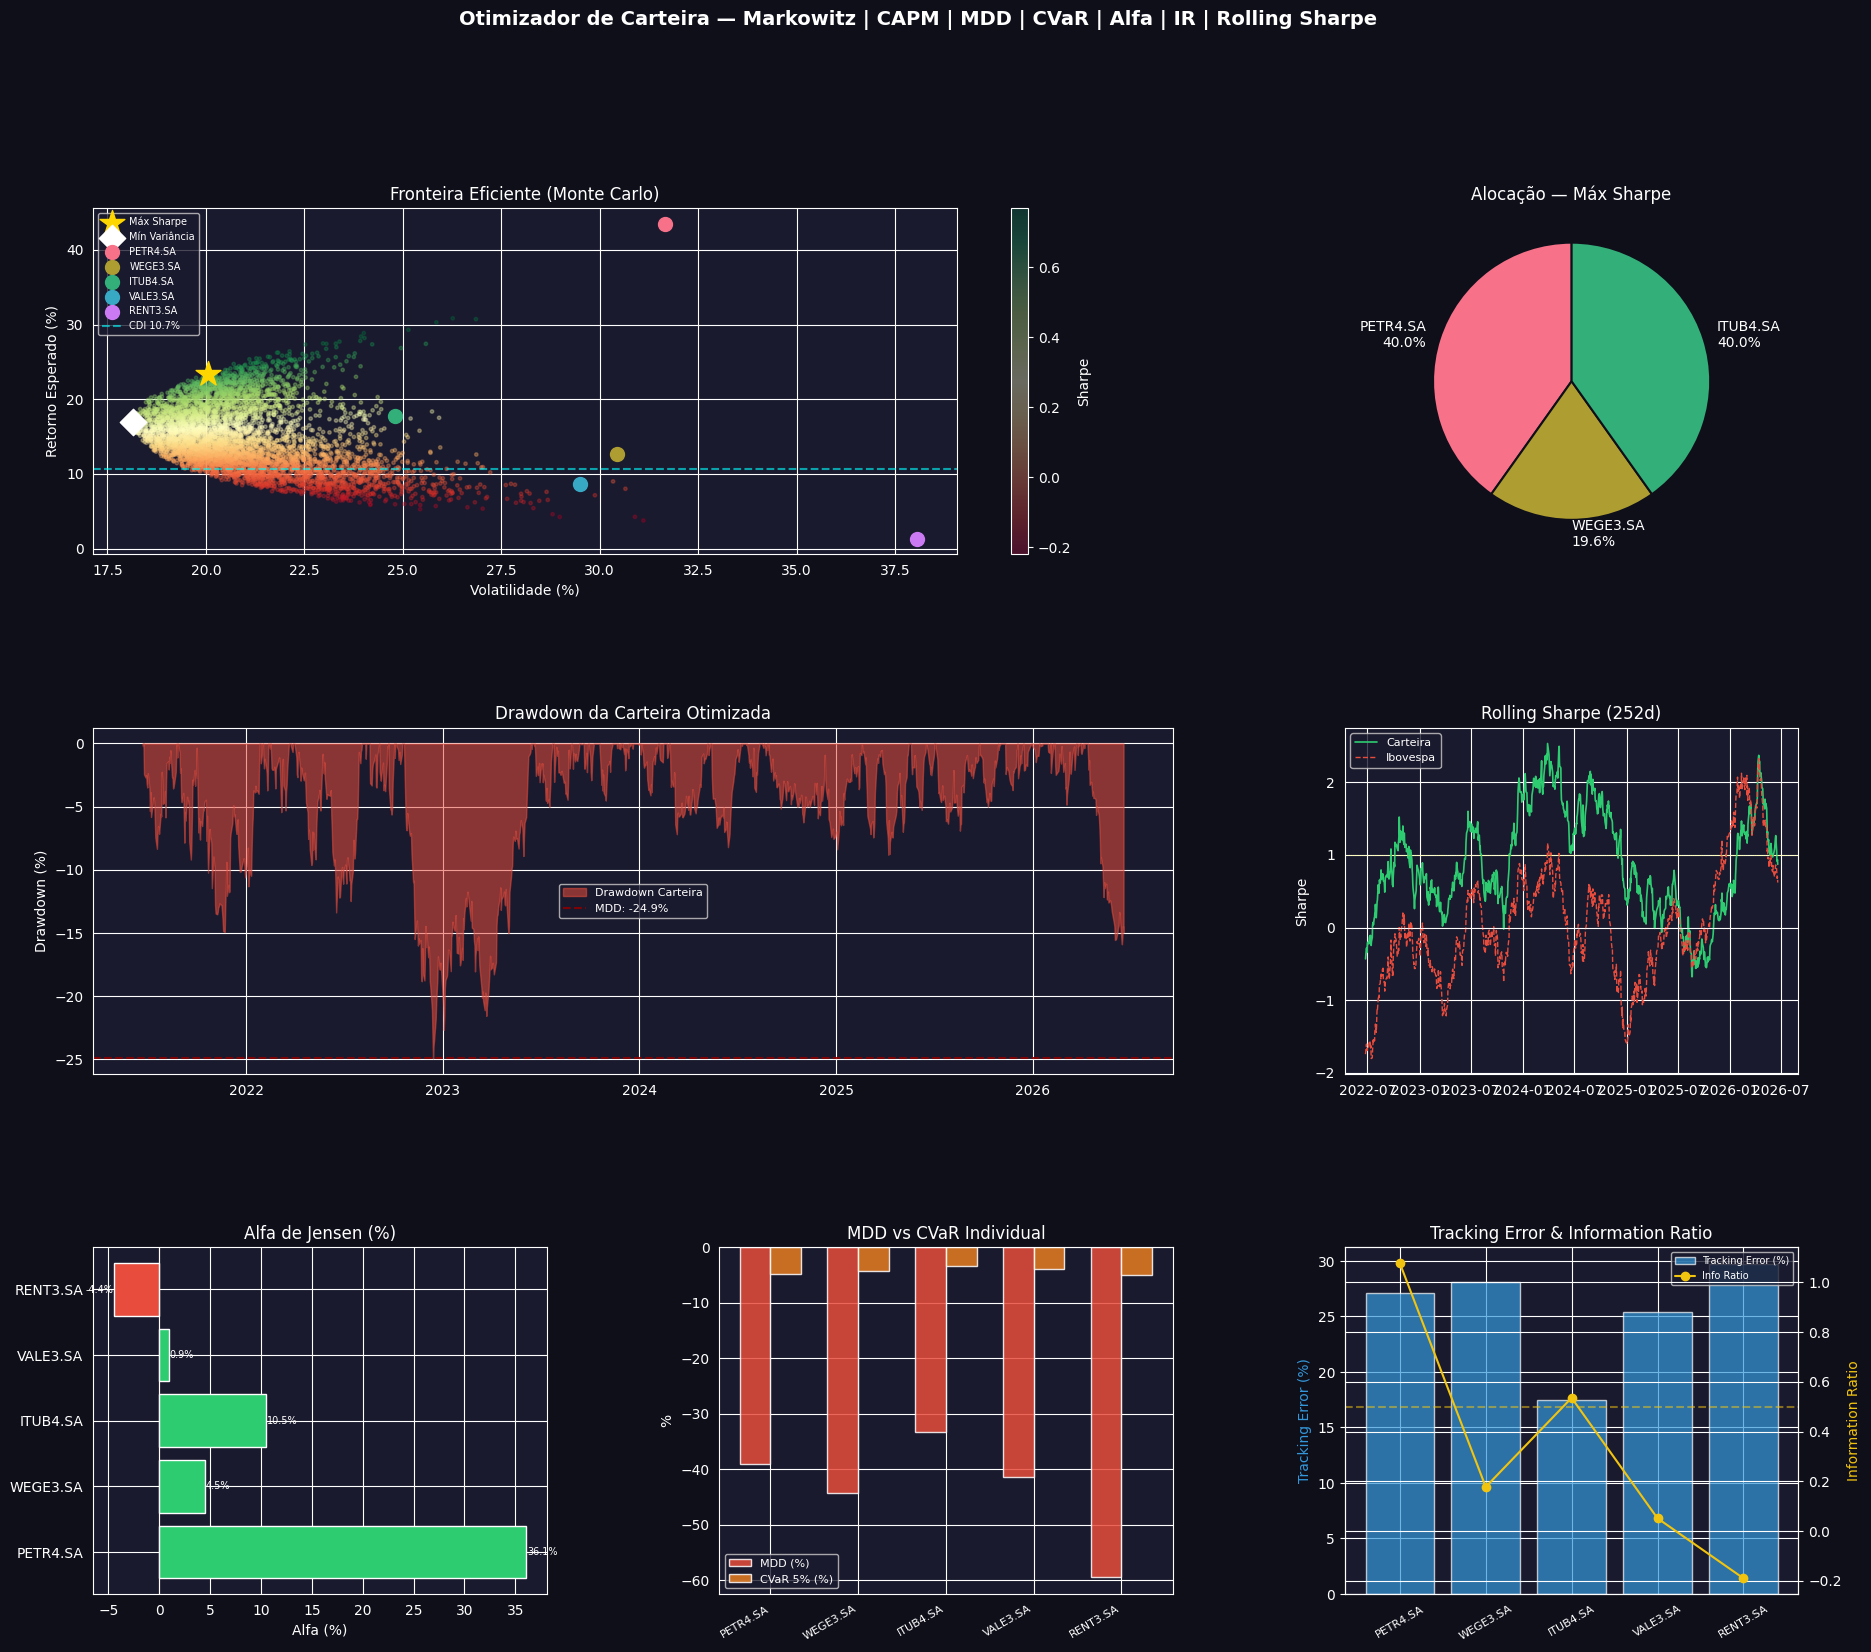


✅ Análise concluída.


In [1]:

"""
================================================================
  OTIMIZADOR DE CARTEIRA — PROTÓTIPO v1
  Markowitz | CAPM | Alfa de Jensen | MDD | CVaR
  Tracking Error | Sharpe | Sortino | IR | Rolling Sharpe
================================================================
Parâmetros da estratégia:
  - Rebalanceamento : Anual
  - Short selling   : Não permitido (long only)
  - Taxa livre de risco: CDI overnight
  - Peso mínimo     : 0%
  - Peso máximo     : 40%

Dependências:
    pip install yfinance numpy pandas scipy matplotlib seaborn

Uso:
    python portfolio_optimizer.py
================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

# ================================================================
# CONFIGURAÇÕES — edite aqui
# ================================================================
TICKERS        = ["PETR4.SA", "WEGE3.SA", "ITUB4.SA", "VALE3.SA", "RENT3.SA"]
BENCHMARK      = "^BVSP"      # Ibovespa
CDI_ANUAL      = 0.1065       # CDI overnight aproximado
PERIODO        = "5y"         # Histórico (mínimo recomendado: 3y)
NUM_PORTFOLIOS = 5000         # Simulações Monte Carlo

# Restrições de peso (long only, sem short)
PESO_MIN = 0.00               # 0% — otimizador pode zerar ativos
PESO_MAX = 0.40               # 40% máximo por ativo

# Rolling Sharpe — janela em dias úteis
ROLLING_WINDOW = 252          # 12 meses

# CVaR — nível de confiança
CVAR_NIVEL = 0.05             # 5% piores dias
# ================================================================


# ----------------------------------------------------------------
# 1. COLETA DE DADOS
# ----------------------------------------------------------------
def baixar_dados(tickers, benchmark, periodo):
    print(f"\n📥 Baixando dados: {tickers} + benchmark {benchmark}...")
    raw = yf.download(
        tickers + [benchmark], period=periodo,
        auto_adjust=True, progress=False
    )["Close"]

    # Handle potential empty DataFrame from yfinance download or all NaNs
    if raw.empty:
        print("❌ Erro: yfinance não retornou dados para os tickers e benchmark fornecidos.")
        return pd.DataFrame(), pd.DataFrame(), pd.Series()

    raw.dropna(how="all", inplace=True)
    raw.ffill(inplace=True)

    ativos = raw[tickers].dropna()
    bench  = raw[benchmark].dropna()

    # Handle cases where individual ticker or benchmark data might become empty after dropna/ffill
    if ativos.empty or bench.empty:
        print("❌ Erro: Após o tratamento de dados, os dados de ativos ou do benchmark estão vazios. Não há dados suficientes para a análise.")
        return pd.DataFrame(), pd.DataFrame(), pd.Series()

    retornos      = ativos.pct_change().dropna()
    retorno_bench = bench.pct_change().dropna()

    # Alinhando datas
    idx = retornos.index.intersection(retorno_bench.index)

    if idx.empty:
        print("❌ Erro: Não há datas em comum após o alinhamento de retornos de ativos e benchmark. Não há dados suficientes para a análise.")
        return pd.DataFrame(), pd.DataFrame(), pd.Series()

    retornos      = retornos.loc[idx]
    retorno_bench = retorno_bench.loc[idx]

    if retornos.empty or retorno_bench.empty: # This check is actually redundant if idx was not empty and loc[idx] is used.
        print("❌ Erro: Retornos de ativos ou benchmark vazios após o alinhamento. Não há dados suficientes para a análise.")
        return pd.DataFrame(), pd.DataFrame(), pd.Series()

    print(f"✅ {len(retornos)} dias úteis "
          f"({retornos.index[0].date()} → {retornos.index[-1].date()})")
    return ativos, retornos, retorno_bench


# ----------------------------------------------------------------
# 2. FUNÇÕES AUXILIARES DE RISCO
# ----------------------------------------------------------------
def calcular_mdd(serie_retornos):
    acum = (1 + serie_retornos).cumprod()
    pico = acum.cummax()
    dd   = (acum - pico) / pico
    return dd.min(), dd

def calcular_cvar(serie_retornos, nivel=CVAR_NIVEL):
    """Perda média nos X% piores dias (CVaR / Expected Shortfall)."""
    corte = serie_retornos.quantile(nivel)
    cvar  = serie_retornos[serie_retornos <= corte].mean()
    return cvar

def calcular_tracking_error(serie_carteira, serie_bench):
    excesso = serie_carteira - serie_bench
    return excesso.std() * np.sqrt(252)

def calcular_rolling_sharpe(serie_retornos, cdi_anual, janela=ROLLING_WINDOW):
    cdi_diario = (1 + cdi_anual) ** (1/252) - 1
    excesso    = serie_retornos - cdi_diario
    rs = excesso.rolling(janela).mean() / excesso.rolling(janela).std()
    return rs * np.sqrt(252)


# ----------------------------------------------------------------
# 3. MÉTRICAS INDIVIDUAIS
# ----------------------------------------------------------------
def calcular_metricas_individuais(retornos, retorno_bench, cdi_anual):
    ret_bench_anual = (1 + retorno_bench.mean()) ** 252 - 1
    metricas = {}

    for ticker in retornos.columns:
        r = retornos[ticker]

        ret_anual = (1 + r.mean()) ** 252 - 1
        vol_anual = r.std() * np.sqrt(252)

        # Beta
        cov   = np.cov(r, retorno_bench)[0, 1]
        beta  = cov / retorno_bench.var()

        # CAPM e Alfa de Jensen
        retorno_capm = cdi_anual + beta * (ret_bench_anual - cdi_anual)
        alfa_jensen  = ret_anual - retorno_capm

        # Sharpe
        sharpe = (ret_anual - cdi_anual) / vol_anual if vol_anual > 0 else 0

        # Sortino
        ret_neg = r[r < 0]
        vol_neg = ret_neg.std() * np.sqrt(252) if len(ret_neg) > 0 else vol_anual
        sortino = (ret_anual - cdi_anual) / vol_neg if vol_neg > 0 else 0

        # MDD
        mdd, _ = calcular_mdd(r)

        # CVaR
        cvar = calcular_cvar(r)

        # Tracking Error
        te = calcular_tracking_error(r, retorno_bench)

        # Information Ratio
        excesso = r - retorno_bench
        ir = (excesso.mean() * 252) / te if te > 0 else 0

        metricas[ticker] = {
            "Retorno Anual (%)": round(ret_anual * 100, 2),
            "Volatilidade (%)":  round(vol_anual * 100, 2),
            "Beta":              round(beta, 3),
            "Retorno CAPM (%)":  round(retorno_capm * 100, 2),
            "Alfa Jensen (%)":   round(alfa_jensen * 100, 2),
            "Sharpe":            round(sharpe, 3),
            "Sortino":           round(sortino, 3),
            "MDD (%)":           round(mdd * 100, 2),
            "CVaR 5% (%)":       round(cvar * 100, 2),
            "Tracking Error (%)":round(te * 100, 2),
            "Info Ratio":        round(ir, 3),
        }

    return pd.DataFrame(metricas).T


# ----------------------------------------------------------------
# 4. OTIMIZAÇÃO DE MARKOWITZ
# ----------------------------------------------------------------
def otimizar_markowitz(retornos, cdi_anual):
    mu    = retornos.mean() * 252
    sigma = retornos.cov() * 252
    n     = len(retornos.columns)

    constraints = {"type": "eq", "fun": lambda x: np.sum(x) - 1}
    bounds      = tuple((PESO_MIN, PESO_MAX) for _ in range(n))
    x0          = np.ones(n) / n

    # Portfólio de Tangência — máximo Sharpe
    def neg_sharpe(pesos):
        ret = np.dot(pesos, mu)
        vol = np.sqrt(pesos @ sigma.values @ pesos)
        return -(ret - cdi_anual) / vol

    res_tang = minimize(neg_sharpe, x0, method="SLSQP",
                        bounds=bounds, constraints=constraints)
    pesos_otimos = res_tang.x

    # Portfólio de Mínima Variância
    def min_var(pesos):
        return pesos @ sigma.values @ pesos

    res_mv   = minimize(min_var, x0, method="SLSQP",
                        bounds=bounds, constraints=constraints)
    pesos_mv = res_mv.x

    return pesos_otimos, pesos_mv, mu, sigma


# ----------------------------------------------------------------
# 5. FRONTEIRA EFICIENTE (Monte Carlo)
# ----------------------------------------------------------------
def fronteira_eficiente(mu, sigma, cdi_anual, n_ativos, n_sim):
    resultados = np.zeros((3, n_sim))
    for i in range(n_sim):
        p   = np.random.dirichlet(np.ones(n_ativos))
        # Aplica restrição de peso máximo via clip + renormalização
        p   = np.clip(p, PESO_MIN, PESO_MAX)
        p  /= p.sum()
        ret = np.dot(p, mu)
        vol = np.sqrt(p @ sigma.values @ p)
        resultados[0, i] = vol
        resultados[1, i] = ret
        resultados[2, i] = (ret - cdi_anual) / vol
    return resultados


# ----------------------------------------------------------------
# 6. MÉTRICAS DA CARTEIRA CONSOLIDADA
# ----------------------------------------------------------------
def metricas_carteira(pesos, retornos, retorno_bench, cdi_anual, nome="Carteira"):
    # Check if retornos is empty before performing dot product
    if retornos.empty:
        print(f"\n❌ Erro: 'retornos' DataFrame está vazio para calcular métricas da {nome}.")
        return {
            "retorno": 0, "vol": 0, "sharpe": 0,
            "sortino": 0, "beta": 0, "capm": 0,
            "alfa": 0, "mdd": 0, "serie_dd": pd.Series(),
            "cvar": 0, "te": 0, "ir": 0, "rolling_sharpe": pd.Series(),
            "calmar": 0, "serie": pd.Series()
        }

    r = pd.Series(retornos.values @ pesos, index=retornos.index)

    ret_anual       = (1 + r.mean()) ** 252 - 1
    vol_anual       = r.std() * np.sqrt(252)
    sharpe          = (ret_anual - cdi_anual) / vol_anual

    # Beta, CAPM, Alfa
    cov             = np.cov(r, retorno_bench)[0, 1]
    beta            = cov / retorno_bench.var()
    ret_bench_anual = (1 + retorno_bench.mean()) ** 252 - 1
    retorno_capm    = cdi_anual + beta * (ret_bench_anual - cdi_anual)
    alfa_jensen     = ret_anual - retorno_capm

    # Sortino
    ret_neg  = r[r < 0]
    vol_neg  = ret_neg.std() * np.sqrt(252) if len(ret_neg) > 0 else vol_anual
    sortino  = (ret_anual - cdi_anual) / vol_neg

    # MDD
    mdd, serie_dd = calcular_mdd(r)

    # CVaR
    cvar = calcular_cvar(r)

    # Tracking Error
    te = calcular_tracking_error(r, retorno_bench)

    # Information Ratio (usa TE já calculado)
    excesso = r - retorno_bench
    ir = (excesso.mean() * 252) / te if te > 0 else 0

    # Rolling Sharpe
    rs = calcular_rolling_sharpe(r, cdi_anual)

    # Calmar
    calmar = ret_anual / abs(mdd) if mdd != 0 else 0

    print(f"\n{'='*55}")
    print(f"  {nome}")
    print(f"{'='*55}")
    print(f"  Retorno Anual      : {ret_anual*100:>8.2f}%")
    print(f"  Volatilidade       : {vol_anual*100:>8.2f}%")
    print(f"  Sharpe             : {sharpe:>8.3f}")
    print(f"  Sortino            : {sortino:>8.3f}")
    print(f"  Beta               : {beta:>8.3f}")
    print(f"  Retorno CAPM       : {retorno_capm*100:>8.2f}%")
    print(f"  Alfa de Jensen     : {alfa_jensen*100:>8.2f}%")
    print(f"  MDD                : {mdd*100:>8.2f}%")
    print(f"  CVaR 5%  (diário)  : {cvar*100:>8.2f}%")
    print(f"  Tracking Error     : {te*100:>8.2f}%")
    print(f"  Information Ratio  : {ir:>8.3f}")
    print(f"  Rolling Sharpe (med): {rs.mean():>7.3f}")
    print(f"  Calmar             : {calmar:>8.3f}")

    return {
        "retorno": ret_anual, "vol": vol_anual, "sharpe": sharpe,
        "sortino": sortino, "beta": beta, "capm": retorno_capm,
        "alfa": alfa_jensen, "mdd": mdd, "serie_dd": serie_dd,
        "cvar": cvar, "te": te, "ir": ir, "rolling_sharpe": rs,
        "calmar": calmar, "serie": r
    }


# ----------------------------------------------------------------
# 7. VISUALIZAÇÕES
# ----------------------------------------------------------------
def plotar_resultados(resultados_fe, pesos_otimos, pesos_mv, mu, sigma,
                      metricas_ind, tickers, cart_otima, cart_mv,
                      cdi_anual, retorno_bench):

    # Prevent plotting if critical data (like cart_otima['serie']) is empty
    if cart_otima["serie"].empty:
        print("❌ Não é possível gerar gráficos: Dados da carteira otimizada estão vazios.")
        return

    sns.set_style("darkgrid")
    plt.rcParams.update({"figure.facecolor": "#0f0f1a", "axes.facecolor": "#1a1a2e",
                         "text.color": "white", "axes.labelcolor": "white",
                         "xtick.color": "white", "ytick.color": "white"})

    fig = plt.figure(figsize=(22, 18))
    fig.suptitle(
        "Otimizador de Carteira — Markowitz | CAPM | MDD | CVaR | Alfa | IR | Rolling Sharpe",
        fontsize=14, fontweight="bold", y=0.99, color="white"
    )
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)
    cores = sns.color_palette("husl", len(tickers))

    # ── Plot 1: Fronteira Eficiente ──────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])
    sc  = ax1.scatter(resultados_fe[0]*100, resultados_fe[1]*100,
                      c=resultados_fe[2], cmap="RdYlGn", alpha=0.35, s=6)
    plt.colorbar(sc, ax=ax1, label="Sharpe")

    vol_ot = np.sqrt(pesos_otimos @ sigma.values @ pesos_otimos) * 100
    ret_ot = np.dot(pesos_otimos, mu) * 100
    vol_mv = np.sqrt(pesos_mv @ sigma.values @ pesos_mv) * 100
    ret_mv = np.dot(pesos_mv, mu) * 100

    ax1.scatter(vol_ot, ret_ot, marker="*", s=350, color="gold",  zorder=5, label="Máx Sharpe")
    ax1.scatter(vol_mv, ret_mv, marker="D", s=180, color="white", zorder=5, label="Mín Variância")
    for i, t in enumerate(tickers):
        ax1.scatter(metricas_ind.loc[t, "Volatilidade (%)"],
                    metricas_ind.loc[t, "Retorno Anual (%)"],
                    marker="o", s=100, color=cores[i], zorder=4, label=t)
    ax1.axhline(cdi_anual*100, color="cyan", linestyle="--", alpha=0.6,
                label=f"CDI {cdi_anual*100:.1f}%")
    ax1.set_xlabel("Volatilidade (%)")
    ax1.set_ylabel("Retorno Esperado (%)")
    ax1.set_title("Fronteira Eficiente (Monte Carlo)")
    ax1.legend(fontsize=7, loc="upper left")

    # ── Plot 2: Alocação pizza ───────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    pesos_validos = pesos_otimos.copy()
    labels_validos = []
    cores_validos  = []
    pesos_plot     = []
    for i, (t, p) in enumerate(zip(tickers, pesos_validos)):
        if p > 0.005:
            labels_validos.append(f"{t}\n{p*100:.1f}%")
            cores_validos.append(cores[i])
            pesos_plot.append(p)
    ax2.pie(pesos_plot, labels=labels_validos, colors=cores_validos,
            startangle=90, wedgeprops={"edgecolor": "#0f0f1a", "linewidth": 1.5})
    ax2.set_title("Alocação — Máx Sharpe")

    # ── Plot 3: Drawdown temporal ────────────────────────────────
    ax3 = fig.add_subplot(gs[1, :2])
    dd  = cart_otima["serie_dd"] * 100
    ax3.fill_between(dd.index, dd, 0, alpha=0.55, color="#e74c3c", label="Drawdown Carteira")
    ax3.axhline(cart_otima["mdd"]*100, color="darkred", linestyle="--",
                alpha=0.9, label=f"MDD: {cart_otima['mdd']*100:.1f}%")
    ax3.set_ylabel("Drawdown (%)")
    ax3.set_title("Drawdown da Carteira Otimizada")
    ax3.legend(fontsize=8)

    # ── Plot 4: Rolling Sharpe carteira vs benchmark ─────────────
    ax4 = fig.add_subplot(gs[1, 2])
    rs_cart  = cart_otima["rolling_sharpe"].dropna()
    rs_bench = calcular_rolling_sharpe(retorno_bench, cdi_anual).dropna()
    idx_comum = rs_cart.index.intersection(rs_bench.index)
    ax4.plot(rs_cart.loc[idx_comum],  color="#2ecc71", linewidth=1.2, label="Carteira")
    ax4.plot(rs_bench.loc[idx_comum], color="#e74c3c", linewidth=1.0, linestyle="--", label="Ibovespa")
    ax4.axhline(0, color="white", linewidth=0.6)
    ax4.axhline(1, color="yellow", linewidth=0.6, linestyle=":", alpha=0.7)
    ax4.set_title(f"Rolling Sharpe ({ROLLING_WINDOW}d)")
    ax4.set_ylabel("Sharpe")
    ax4.legend(fontsize=8)

    # ── Plot 5: Alfa de Jensen individual ───────────────────────
    ax5 = fig.add_subplot(gs[2, 0])
    alfas  = metricas_ind["Alfa Jensen (%)"].astype(float).values
    c_alfa = ["#2ecc71" if a > 0 else "#e74c3c" for a in alfas]
    bars   = ax5.barh(tickers, alfas, color=c_alfa)
    ax5.axvline(0, color="white", linewidth=0.8)
    ax5.set_title("Alfa de Jensen (%)")
    ax5.set_xlabel("Alfa (%)")
    for bar, v in zip(bars, alfas):
        ax5.text(v + (0.1 if v >= 0 else -0.1),
                 bar.get_y() + bar.get_height()/2,
                 f"{v:.1f}%", va="center", ha="left" if v >= 0 else "right", fontsize=7)

    # ── Plot 6: CVaR e MDD individuais ──────────────────────────
    ax6   = fig.add_subplot(gs[2, 1])
    mdds  = metricas_ind["MDD (%)"].astype(float).values
    cvars = metricas_ind["CVaR 5% (%)"].astype(float).values
    x     = np.arange(len(tickers))
    w     = 0.35
    ax6.bar(x - w/2, mdds,  w, label="MDD (%)",      color="#e74c3c", alpha=0.85)
    ax6.bar(x + w/2, cvars, w, label="CVaR 5% (%)",  color="#e67e22", alpha=0.85)
    ax6.set_xticks(x)
    ax6.set_xticklabels(tickers, rotation=30, ha="right", fontsize=8)
    ax6.set_title("MDD vs CVaR Individual")
    ax6.set_ylabel("%")
    ax6.legend(fontsize=8)

    # ── Plot 7: Tracking Error e IR individual ───────────────────
    ax7   = fig.add_subplot(gs[2, 2])
    tes   = metricas_ind["Tracking Error (%)"].astype(float).values
    irs   = metricas_ind["Info Ratio"].astype(float).values
    ax7b  = ax7.twinx()
    ax7.bar(tickers, tes, color="#3498db", alpha=0.7, label="Tracking Error (%)")
    ax7b.plot(tickers, irs, color="#f1c40f", marker="o", linewidth=1.5,
              markersize=6, label="Info Ratio")
    ax7b.axhline(0.5, color="#f1c40f", linestyle="--", alpha=0.5)
    ax7.set_title("Tracking Error & Information Ratio")
    ax7.set_ylabel("Tracking Error (%)", color="#3498db")
    ax7b.set_ylabel("Information Ratio", color="#f1c40f")
    ax7.tick_params(axis="x", rotation=30, labelsize=8)
    lines1, labels1 = ax7.get_legend_handles_labels()
    lines2, labels2 = ax7b.get_legend_handles_labels()
    ax7.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper right")

    plt.savefig("portfolio_resultado.png", dpi=150, bbox_inches="tight",
                facecolor="#0f0f1a", edgecolor="none")
    print("\n📊 Gráfico salvo em: portfolio_resultado.png")
    plt.show()


# ----------------------------------------------------------------
# 8. TABELA RESUMO FINAL
# ----------------------------------------------------------------
def tabela_resumo(metricas_ind, pesos_otimos, pesos_mv, tickers):
    # Check if metricas_ind is empty
    if metricas_ind.empty:
        print("\n❌ Não é possível gerar a tabela de métricas individuais: Dados vazios.")
        return

    print("\n" + "="*70)
    print("  MÉTRICAS INDIVIDUAIS")
    print("="*70)
    print(metricas_ind.to_string())

    print("\n" + "="*70)
    print("  PESOS — CARTEIRA ÓTIMA (Máx Sharpe)")
    print("="*70)
    ativos_ativos = [(t, p) for t, p in zip(tickers, pesos_otimos) if p > 0.005]
    for t, p in sorted(ativos_ativos, key=lambda x: -x[1]):
        barra = "█" * int(p * 40)
        print(f"  {t:<12}: {p*100:>5.1f}%  {barra}")

    print("\n" + "="*70)
    print("  PESOS — MÍNIMA VARIÂNCIA")
    print("="*70)
    for t, p in zip(tickers, pesos_mv):
        if p > 0.005:
            barra = "█" * int(p * 40)
            print(f"  {t:<12}: {p*100:>5.1f}%  {barra}")

    print("\n" + "="*70)
    print("  GUIA DE INTERPRETAÇÃO")
    print("="*70)
    print("""
  Sharpe        > 1.0    → Excelente relação retorno/risco
  Sortino       > 1.0    → Baixa volatilidade negativa
  Beta          < 1.0    → Menos sensível ao mercado que o Ibovespa
  Alfa Jensen   > 0%     → Gerou retorno além do exigido pelo CAPM
  MDD           próx 0   → Menor sequência de perda histórica
  CVaR 5%       próx 0   → Baixa perda média nos dias extremos
  Tracking Error baixo   → Não depende de apostas grandes no benchmark
  Info Ratio    > 0.5    → Alfa consistente e recorrente
  Rolling Sharpe > bench → Superação consistente ao longo do tempo
  Calmar        > 1.0    → Bom retorno relativo ao pior drawdown
    """)


# ----------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------
def main():
    print("\n" + "="*55)
    print("  OTIMIZADOR DE CARTEIRA — PROTÓTIPO v1")
    print(f"  Tickers    : {TICKERS}")
    print(f"  Benchmark  : {BENCHMARK}")
    print(f"  CDI anual  : {CDI_ANUAL*100:.2f}%")
    print(f"  Período    : {PERIODO}")
    print(f"  Pesos      : [{PESO_MIN*100:.0f}%, {PESO_MAX*100:.0f}%]  |  Long only")
    print(f"  Rebalanc.  : Anual")
    print("="*55)

    # 1. Dados
    _, retornos, retorno_bench = baixar_dados(TICKERS, BENCHMARK, PERIODO)

    # Exit if no data was successfully downloaded/processed
    if retornos.empty or retorno_bench.empty:
        print("🔴 Análise interrompida: Não foi possível obter dados suficientes para prosseguir.")
        return

    # 2. Métricas individuais
    print("\n📐 Calculando métricas individuais...")
    metricas_ind = calcular_metricas_individuais(retornos, retorno_bench, CDI_ANUAL)

    # 3. Otimização Markowitz
    print("⚙️  Otimizando carteira (Markowitz)...")
    pesos_otimos, pesos_mv, mu, sigma = otimizar_markowitz(retornos, CDI_ANUAL)

    # 4. Fronteira eficiente
    print(f"🎲 Simulando {NUM_PORTFOLIOS} portfólios (Monte Carlo)...")
    resultados_fe = fronteira_eficiente(mu, sigma, CDI_ANUAL, len(TICKERS), NUM_PORTFOLIOS)

    # 5. Métricas das carteiras
    cart_otima = metricas_carteira(pesos_otimos, retornos, retorno_bench,
                                   CDI_ANUAL, "CARTEIRA ÓTIMA (Máx Sharpe)")
    cart_mv    = metricas_carteira(pesos_mv, retornos, retorno_bench,
                                   CDI_ANUAL, "CARTEIRA MÍNIMA VARIÂNCIA")

    # 6. Tabela resumo
    tabela_resumo(metricas_ind, pesos_otimos, pesos_mv, TICKERS)

    # 7. Gráficos
    print("\n🎨 Gerando visualizações...")
    plotar_resultados(resultados_fe, pesos_otimos, pesos_mv, mu, sigma,
                      metricas_ind, TICKERS, cart_otima, cart_mv,
                      CDI_ANUAL, retorno_bench)

    print("\n✅ Análise concluída.")


if __name__ == "__main__":
    main()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful